In [1]:
# Import required libraries

# To load and manipulate data
import numpy as np
import pandas as pd

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To split the data into train and test sets
from sklearn.model_selection import train_test_split

# To preprocess data
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# To build a linear regression model
from sklearn.neighbors import KNeighborsRegressor

# To check a regression model's performance
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_log_error, r2_score, mean_squared_error

In [2]:
# Import dataset
df=pd.read_csv('Housing_KNN.csv')
df.shape

(545, 13)

In [ ]:
        # --------Perform Exploratory Data Analysis--------#

In [3]:
# Show the dataset
df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


In [ ]:
# price: Market selling price of the house
# area: Total built-up area or size of the house
# bedrooms: Number of bedrooms in the house
# bathrooms: Number of bathrooms available in the house
# stories: Total number of floors the house has
# mainroad: Indicates whether the house is located on the main road (Yes/No)
# guestroom: Specifies if a separate guest room is available (Yes/No)
# basement: Indicates whether the house has a basement (Yes/No)
# hotwaterheating: Shows availability of hot water heating facility (Yes/No)
# airconditioning: Indicates if the house has air conditioning (Yes/No)
# parking: Number of parking spaces available with the property
# prefarea: Indicates whether the house is located in a preferred residential area (Yes/No)
# furnishingstatus: Describes whether the house is furnished, semi-furnished, or unfurnished

In [4]:
# Check basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
# Display descriptive statistics of the dataset
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
# Checking whether it has null value
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
# Checking any duplicated value
df.duplicated().sum()

np.int64(0)

In [ ]:
        ##-----Basic Information-----#
# The dataset contain total 545 samples and 13 columns
# There are no missing values in any features
# There are no duplicated values.
# So data is clean and ready for further analysis

In [ ]:
                #---------Perform Univariate analysis---------#

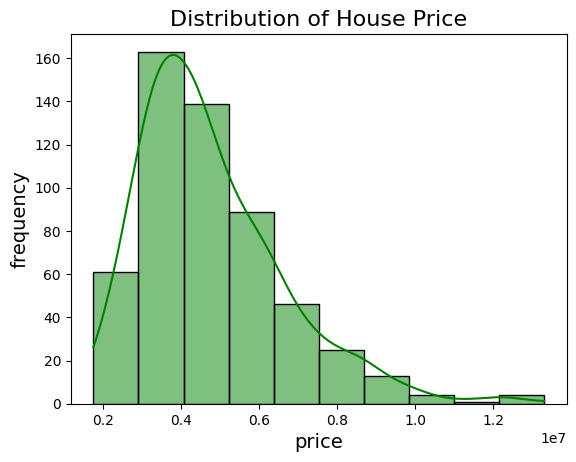

In [12]:
# Visualize the distribution of 'price' using histogram
plt.Figure(figsize=(4,4))
sns.histplot(df['price'], kde=True, color='green', bins=10)
plt.title('Distribution of House Price', fontsize=16)
plt.xlabel('price', fontsize=14)
plt.ylabel('frequency', fontsize=14)
plt.show()

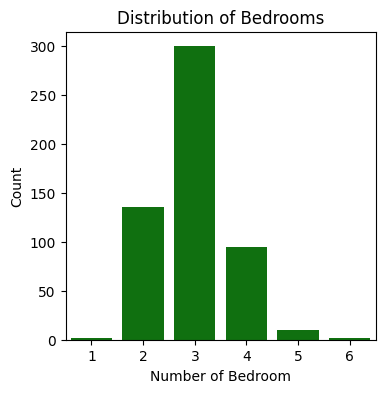

In [27]:
# Visualize the distribution of 'bedrooms' using a bar plot
plt.figure(figsize=(4,4))
sns.countplot(x='bedrooms', data=df, color='green')
plt.title('Distribution of Bedrooms')
plt.xlabel('Number of Bedroom')
plt.ylabel('Count')
plt.show()

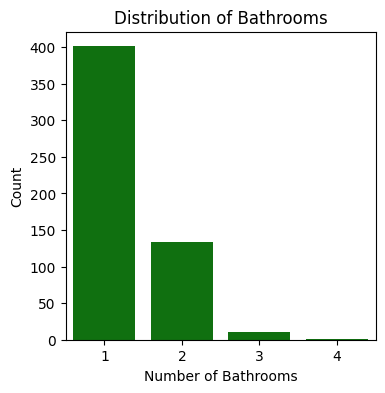

In [26]:
# Visualize the distribution of 'bathrooms' using a bar plot
plt.figure(figsize=(4,4))
sns.countplot(x='bathrooms', data=df, color='green')
plt.title('Distribution of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count')
plt.show()

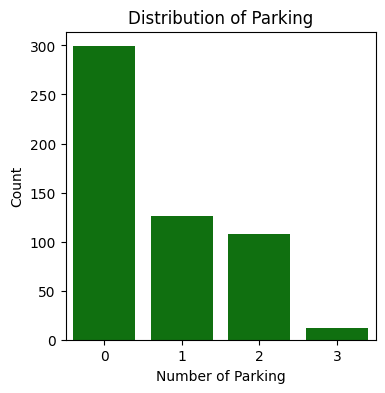

In [25]:
# Visualize the distribution of 'parking' using a bar plot
plt.figure(figsize=(4,4))
sns.countplot(x='parking', data=df, color='green')
plt.title('Distribution of Parking')
plt.xlabel('Number of Parking')
plt.ylabel('Count')
plt.show()

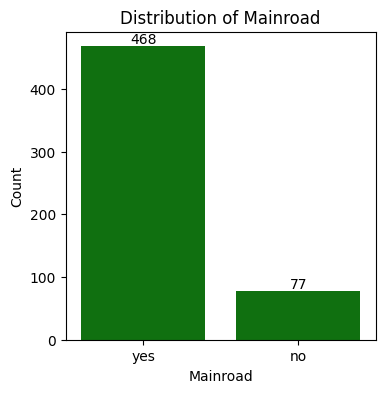

In [24]:
# Visualize the distribution of 'mainroad' using a bar plot
plt.figure(figsize=(4,4))
ax=sns.countplot(x='mainroad', data=df, color='green')
plt.title('Distribution of Mainroad')
plt.xlabel('Mainroad')
plt.ylabel('Count')
# Add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')
plt.show()

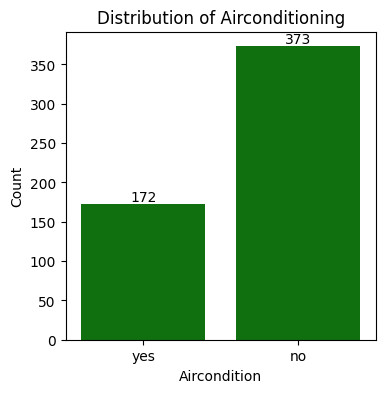

In [29]:
# Visualize the distribution of 'airconditioning' using a bar plot
plt.figure(figsize=(4,4))
ax=sns.countplot(x='airconditioning', data=df, color='green')
plt.title('Distribution of Airconditioning')
plt.xlabel('Aircondition')
plt.ylabel('Count')
# Add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')
plt.show()

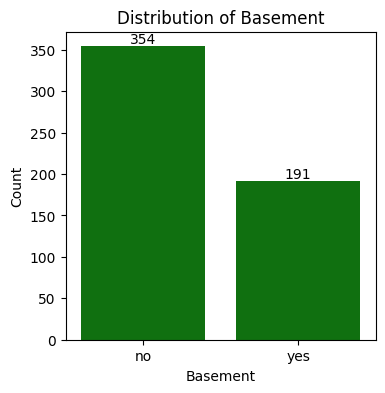

In [30]:
# Visualize the distribution of 'basement' using a bar plot
plt.figure(figsize=(4,4))
ax=sns.countplot(x='basement', data=df, color='green')
plt.title('Distribution of Basement')
plt.xlabel('Basement')
plt.ylabel('Count')
# Add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')
plt.show()

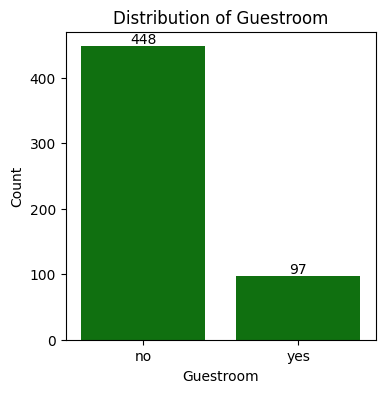

In [32]:
# Visualize the distribution of 'guestroom' using a bar plot
plt.figure(figsize=(4,4))
ax=sns.countplot(x='guestroom', data=df, color='green')
plt.title('Distribution of Guestroom')
plt.xlabel('Guestroom')
plt.ylabel('Count')
# Add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')
plt.show()

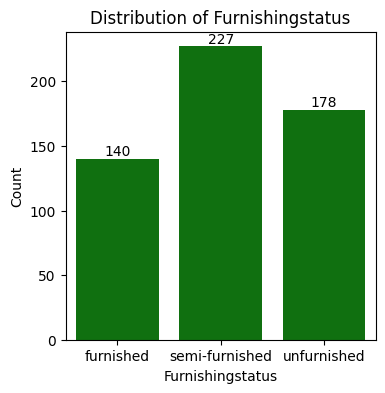

In [33]:
# Visualize the distribution of 'Furnishingstatus' using a bar plot
plt.figure(figsize=(4,4))
ax=sns.countplot(x='furnishingstatus', data=df, color='green')
plt.title('Distribution of Furnishingstatus')
plt.xlabel('Furnishingstatus')
plt.ylabel('Count')
# Add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')
plt.show()

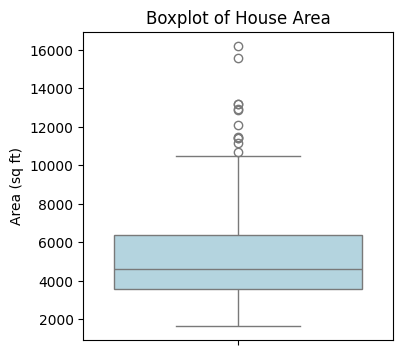

In [35]:
# Boxplot of area feature
# Visualize the distribution of 'airconditioning' using a bar plot
plt.figure(figsize=(4,4))
ax=sns.boxplot(y='area', data=df, color='lightblue')
plt.title('Boxplot of House Area')
plt.ylabel('Area (sq ft)')
plt.show()

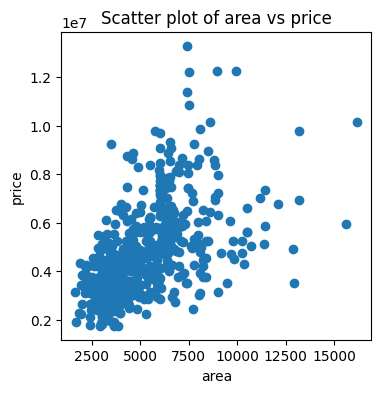

In [37]:
# Create scatter plot of 'area vs price'
plt.figure(figsize=(4,4))
plt.scatter(x='area', y='price', data=df)
plt.title('Scatter plot of area vs price')
plt.xlabel('area')
plt.ylabel('price')
plt.show()

<Axes: >

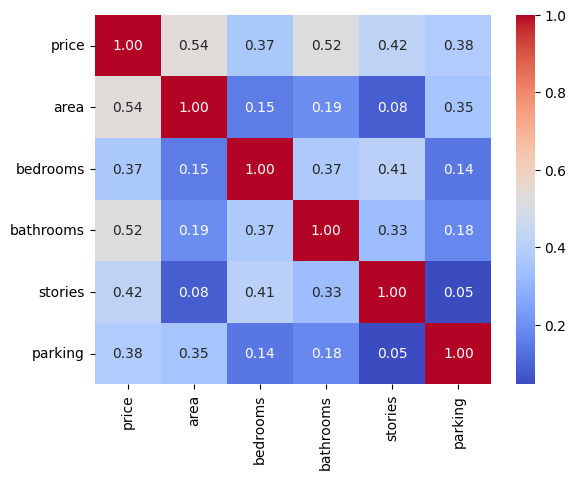

In [ ]:
# Draw a heatmap to show the relationsip between numeric column
corr=df.corr(numeric_only=True)

plt.Figure(figsize=(4,4))
sns.heatmap(corr, annot=True, fmt='0.2f', cmap='coolwarm' )

In [ ]:
        #-------Finding after Univariate and Correlation Analysis-----#
#  Price shows a moderate positive correlation with area
#  Price is positively correlated with the numver of bedrooms, bathrooms, parking, stories.

In [ ]:
            #--------Bivariate Analysis---------#

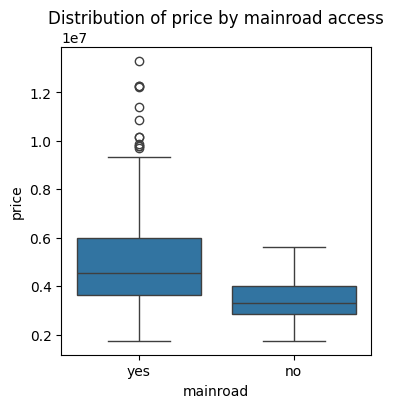

In [43]:
# Show the distribution of price by mainroad access
plt.figure(figsize=(4,4))
sns.boxplot(data=df, x='mainroad', y='price')
plt.title('Distribution of price by mainroad access')
plt.xlabel('mainroad')
plt.ylabel('price')
plt.show()

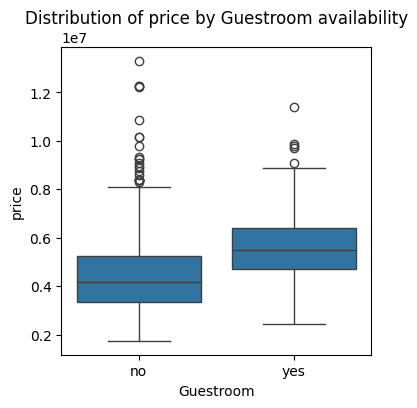

In [45]:
# Show the distribution of price by Guestroom availability
plt.figure(figsize=(4,4))
sns.boxplot(data=df, x='guestroom', y='price')
plt.title('Distribution of price by Guestroom availability')
plt.xlabel('Guestroom')
plt.ylabel('price')
plt.show()

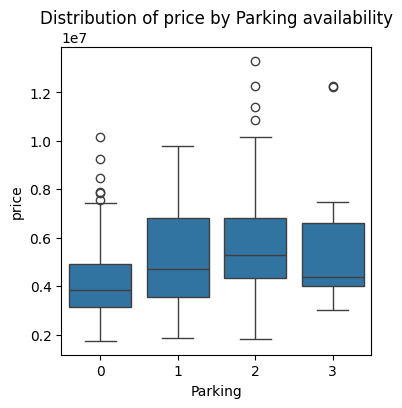

In [46]:
# Show the distribution of price by Parking availability
plt.figure(figsize=(4,4))
sns.boxplot(data=df, x='parking', y='price')
plt.title('Distribution of price by Parking availability')
plt.xlabel('Parking')
plt.ylabel('price')
plt.show()

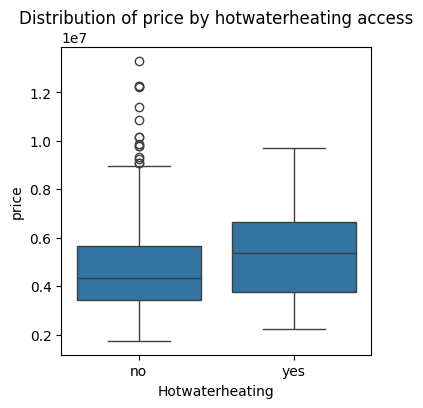

In [3]:
# Show the distribution of price by hotwaterheating
plt.figure(figsize=(4,4))
sns.boxplot(data=df, x='hotwaterheating', y='price')
plt.title('Distribution of price by hotwaterheating access')
plt.xlabel('Hotwaterheating')
plt.ylabel('price')
plt.show()

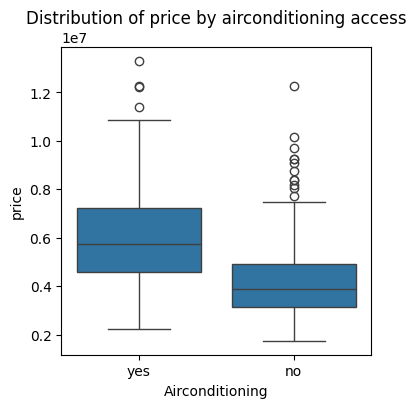

In [4]:
# Show the distribution of price by airconditioning access
plt.figure(figsize=(4,4))
sns.boxplot(data=df, x='airconditioning', y='price')
plt.title('Distribution of price by airconditioning access')
plt.xlabel('Airconditioning')
plt.ylabel('price')
plt.show()

In [ ]:
            #-------Findings after Multivariate analysis---------#
# Houses which located near main road have higher price
# Houses which have airconditioning, guestroom, parking, hot water facility show high price

In [ ]:
            #--------Now perform Data Cleaning-------#
# In this dataset there are no missing value and duplication.
# So, no need to perform missing value imputation and remove duplication

In [ ]:
# Here, we perform cleaning on categorical dataset
column_t_clean=[
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea']
df[column_t_clean]=df[column_t_clean].apply(lambda x: x.str.strip().str.lower())


In [ ]:
            #--------Now perform Feature Engineering------#

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
cat_encoder = OneHotEncoder(sparse_output=False)
status = data[["furnishingstatus"]]
housing_cat_hot = cat_encoder.fit_transform(status)
housing_cat_hot

In [ ]:
housing_cat_hot = pd.DataFrame(housing_cat_hot, columns=["furnished", "semi-furnished", "unfurnished"], index=status.index)
housing_cat_hot

In [ ]:
data = pd.concat([data, housing_cat_hot], axis=1)
data = data.drop("furnishingstatus", axis=1)
data

In [ ]:
col = ["mainroad",	"guestroom",	"basement",	"hotwaterheating",	"airconditioning", "prefarea"]
for i in col:
    data[i] = data[i].map({"yes": 1, "no": 0})

In [ ]:
df['basement'] = df['basement'].map({'no':0, 'yes':1})
df['airconditioning'] = df['airconditioning'].map({'no':1, 'yes':1})
df['prefarea'] = df['prefarea'].map({'no':0, 'yes':1})
df['mainroad'] = df['mainroad'].map({'yes':1, 'no':0})
df['guestroom'] = df['guestroom'].map({'no':0, 'yes':1})

In [ ]:
df['furnishingstatus'] = df['furnishingstatus'].map({'semi-furnished':1, 'unfurnished':2, "furnished":0})

In [ ]:
# Categorical
# Binary encode one-hot
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[binary_columns] = df[binary_columns].apply(lambda x: x.map({'yes': 1, 'no': 0}))

# Categorical
furnished_map = {'furnished': 1, 'unfurnished': 0, 'semi-furnished': 0.5}
df['furnishingstatus'] = df['furnishingstatus'].map(furnished_map)
df[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']].head()

In [ ]:
# Scaler
scaler = StandardScaler()
preprocessor = ColumnTransformer(
    transformers = [
        ("scaler", scaler, ['area_log', 'bedrooms', 'area_per_bedroom', 'bedrooms_x_stories', 'bathrooms', 'stories', 'parking', 'area_per_room', 'area_pref_interaction'])
    ],
    remainder="passthrough"
)
preprocessor.set_output(transform="pandas")

In [ ]:
https://www.kaggle.com/datasets/harishkumardatalab/housing-price-prediction/code
https://www.kaggle.com/code/suyogbakliwal/case-study-housing-price-projects-sb-kgl